In [1]:
import pandas as pd

print("Python is working!")
print("Pandas version:", pd.__version__)

Python is working!
Pandas version: 2.3.3


In [2]:
import os

data_path = "../data/2019-Dec.csv"

print(os.path.exists(data_path))

True


In [3]:
df_sample = pd.read_csv(data_path, nrows=10)

df_sample

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5
5,2019-12-01 00:00:09 UTC,view,5773361,1487580005134238553,NaN,runail,2.62,560109803,38cf4ba1-4a0a-4c9e-b870-46685d105f95
6,2019-12-01 00:00:18 UTC,cart,5629988,1487580009311764506,NaN,NaN,1.19,579966747,1512be50-d0fd-4a92-bcd8-3ea3943f2a3b
7,2019-12-01 00:00:22 UTC,view,5807805,1487580005713052531,NaN,ingarden,4.44,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5
8,2019-12-01 00:00:27 UTC,view,5588608,1487580008145748965,NaN,roubloff,5.40,546170008,676d9fcc-2a4f-4448-b49d-136f2e4208c1
9,2019-12-01 00:00:34 UTC,cart,5335,1487580009605365797,NaN,runail,0.40,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554


In [4]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     10 non-null     object 
 1   event_type     10 non-null     object 
 2   product_id     10 non-null     int64  
 3   category_id    10 non-null     int64  
 4   category_code  0 non-null      float64
 5   brand          8 non-null      object 
 6   price          10 non-null     float64
 7   user_id        10 non-null     int64  
 8   user_session   10 non-null     object 
dtypes: float64(2), int64(3), object(4)
memory usage: 848.0+ bytes


In [5]:
df_sample.isnull().sum()

event_time        0
event_type        0
product_id        0
category_id       0
category_code    10
brand             2
price             0
user_id           0
user_session      0
dtype: int64

In [6]:
with open(data_path, "r", encoding="utf-8") as f:
    row_count = sum(1 for _ in f) - 1

print("Total rows:", row_count)

Total rows: 3533286


In [7]:
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 3533286
Columns: 9


In [8]:
df["event_type"].value_counts()

event_type
view                1728331
cart                 927124
remove_from_cart     664655
purchase             213176
Name: count, dtype: int64

In [9]:
print("Unique users:", df["user_id"].nunique())

Unique users: 370154


In [10]:
print("Unique sessions:", df["user_session"].nunique())
print("Unique products:", df["product_id"].nunique())
print("Unique categories:", df["category_id"].nunique())
print("Unique brands:", df["brand"].nunique())

Unique sessions: 839812
Unique products: 44624
Unique categories: 482
Unique brands: 252


In [11]:
df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    3474821
brand            1510289
price                  0
user_id                0
user_session         779
dtype: int64

In [12]:
df["event_type"].unique()

array(['remove_from_cart', 'view', 'cart', 'purchase'], dtype=object)

In [13]:
event_counts = df["event_type"].value_counts()

event_summary = pd.DataFrame({
    "Events": event_counts,
    "Percentage": (event_counts / len(df) * 100).round(2)
})

event_summary

,Events,Percentage
event_type,,
view,1728331,48.92
cart,927124,26.24
remove_from_cart,664655,18.81
purchase,213176,6.03


In [14]:
funnel = df.groupby("event_type")["user_id"].nunique()

funnel

event_type
cart                 83458
purchase             25613
remove_from_cart     45217
view                358212
Name: user_id, dtype: int64

In [15]:
view_users = set(df.loc[df["event_type"] == "view", "user_id"])
cart_users = set(df.loc[df["event_type"] == "cart", "user_id"])
purchase_users = set(df.loc[df["event_type"] == "purchase", "user_id"])

view_to_cart = len(cart_users & view_users)
cart_to_purchase = len(purchase_users & cart_users)
view_to_purchase = len(purchase_users & view_users)

print("Users who viewed:", len(view_users))
print("Viewed + added to cart:", view_to_cart)
print("Added to cart + purchased:", cart_to_purchase)
print("Viewed + purchased:", view_to_purchase)

Users who viewed: 358212
Viewed + added to cart: 72359
Added to cart + purchased: 25290
Viewed + purchased: 23893


In [16]:
view_to_cart_rate = view_to_cart / len(view_users) * 100
cart_to_purchase_rate = cart_to_purchase / len(cart_users & view_users) * 100
view_to_purchase_rate = view_to_purchase / len(view_users) * 100

print(f"View → Cart: {view_to_cart_rate:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase_rate:.2f}%")
print(f"View → Purchase: {view_to_purchase_rate:.2f}%")

View → Cart: 20.20%
Cart → Purchase: 34.95%
View → Purchase: 6.67%


In [17]:
top_products = (
    df[df["event_type"] == "purchase"]
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_id
5809910    1659
5854897     786
5802432     714
5700037     621
5809912     620
5833330     594
5304        549
5751422     548
5815662     521
5751383     435
dtype: int64

In [18]:
top_product_ids = top_products.index

top_product_details = (
    df[df["product_id"].isin(top_product_ids)]
    [["product_id", "category_code", "brand", "price"]]
    .drop_duplicates("product_id")
    .set_index("product_id")
    .loc[top_product_ids]
)

top_product_details

,category_code,brand,price
product_id,,,
5809910,NaN,grattol,5.24
5854897,NaN,irisk,0.32
5802432,NaN,NaN,0.32
5700037,NaN,runail,0.40
5809912,NaN,grattol,5.24
5833330,NaN,bpw.style,0.95
5304,NaN,runail,0.32
5751422,NaN,uno,10.95
5815662,NaN,NaN,0.92


In [19]:
top_product_categories = (
    df[df["product_id"].isin(top_product_ids)]
    [["product_id", "category_id", "category_code", "brand", "price"]]
    .drop_duplicates("product_id")
    .set_index("product_id")
    .loc[top_product_ids]
)

top_product_categories

,category_id,category_code,brand,price
product_id,,,,
5809910,1602943681873052386,NaN,grattol,5.24
5854897,1487580009445982239,NaN,irisk,0.32
5802432,1487580009286598681,NaN,NaN,0.32
5700037,1487580009286598681,NaN,runail,0.40
5809912,1602943681873052386,NaN,grattol,5.24
5833330,1487580007675986893,NaN,bpw.style,0.95
5304,1487580009471148064,NaN,runail,0.32
5751422,1487580005268456287,NaN,uno,10.95
5815662,1487580006317032337,NaN,NaN,0.92


In [20]:
top_brands = (
    df[df["event_type"] == "purchase"]
    .groupby("brand")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

top_brands

brand
runail       18199
irisk        10583
grattol       8171
bpw.style     7014
masura        6985
ingarden      4157
estel         4116
kapous        3196
pole          3080
uno           2780
freedecor     2633
italwax       2513
milv          2218
domix         2118
bluesky       2048
dtype: int64

In [21]:
brand_performance = (
    df.groupby(["brand", "event_type"])
    .size()
    .unstack(fill_value=0)
)

brand_performance["view_to_purchase_rate"] = (
    brand_performance["purchase"] / brand_performance["view"] * 100
)

brand_performance = (
    brand_performance
    .sort_values("view_to_purchase_rate", ascending=False)
)

brand_performance.head(15)

event_type,cart,purchase,remove_from_cart,view,view_to_purchase_rate
brand,,,,,
eunyul,858,224,446,411,54.501217
philips,1,1,4,2,50.000000
dermal,645,112,454,268,41.791045
elskin,538,136,255,332,40.963855
supertan,209,37,54,100,37.000000
soleo,970,172,230,487,35.318275
severina,4436,1550,2416,4423,35.044088
farmstay,2490,578,1042,1769,32.673827
swarovski,2671,790,2318,2544,31.053459


In [22]:
reliable_brands = (
    brand_performance[brand_performance["view"] >= 1000]
    .sort_values("view_to_purchase_rate", ascending=False)
)

reliable_brands.head(15)

event_type,cart,purchase,remove_from_cart,view,view_to_purchase_rate
brand,,,,,
severina,4436,1550,2416,4423,35.044088
farmstay,2490,578,1042,1769,32.673827
swarovski,2671,790,2318,2544,31.053459
benovy,1230,382,788,1258,30.365660
dizao,1921,477,897,1648,28.944175
skinlite,1328,296,803,1139,25.987709
airnails,4726,1378,2996,5330,25.853659
shary,1279,309,647,1313,23.533892
nagaraku,7134,1326,2818,5836,22.721042


In [23]:
brand_analysis = reliable_brands.copy()

total_purchases = df[df["event_type"] == "purchase"].shape[0]

brand_analysis["purchase_share"] = (
    brand_analysis["purchase"] / total_purchases * 100
)

brand_analysis[
    ["view", "purchase", "view_to_purchase_rate", "purchase_share"]
].head(15)

event_type,view,purchase,view_to_purchase_rate,purchase_share
brand,,,,
severina,4423,1550,35.044088,0.727099
farmstay,1769,578,32.673827,0.271137
swarovski,2544,790,31.053459,0.370586
benovy,1258,382,30.365660,0.179195
dizao,1648,477,28.944175,0.223759
skinlite,1139,296,25.987709,0.138852
airnails,5330,1378,25.853659,0.646414
shary,1313,309,23.533892,0.144951
nagaraku,5836,1326,22.721042,0.622021


In [24]:
df["event_time"] = pd.to_datetime(df["event_time"])

print(df["event_time"].dtype)

datetime64[ns, UTC]


In [25]:
df["date"] = df["event_time"].dt.date
df["day_of_week"] = df["event_time"].dt.day_name()
df["hour"] = df["event_time"].dt.hour

df[["event_time", "date", "day_of_week", "hour"]].head()

,event_time,date,day_of_week,hour
0,2019-12-01 00:00:00+00:00,2019-12-01,Sunday,0
1,2019-12-01 00:00:00+00:00,2019-12-01,Sunday,0
2,2019-12-01 00:00:02+00:00,2019-12-01,Sunday,0
3,2019-12-01 00:00:05+00:00,2019-12-01,Sunday,0
4,2019-12-01 00:00:07+00:00,2019-12-01,Sunday,0


In [26]:
daily_purchases = (
    df[df["event_type"] == "purchase"]
    .groupby("date")
    .size()
    .sort_values(ascending=False)
)

daily_purchases.head(10)

date
2019-12-10    9794
2019-12-12    9396
2019-12-11    9390
2019-12-09    9294
2019-12-16    9226
2019-12-02    9079
2019-12-17    8425
2019-12-04    8371
2019-12-03    8217
2019-12-18    7818
dtype: int64

In [27]:
hourly_purchases = (
    df[df["event_type"] == "purchase"]
    .groupby("hour")
    .size()
    .sort_values(ascending=False)
)

hourly_purchases

hour
11    14850
10    13894
12    13138
9     12642
13    12455
20    12268
14    11993
8     11884
18    11703
19    11629
17    11046
7     10871
15    10582
16    10405
21     8896
6      8496
5      6068
22     5809
4      3321
23     2846
3      2734
0      2003
2      1995
1      1648
dtype: int64

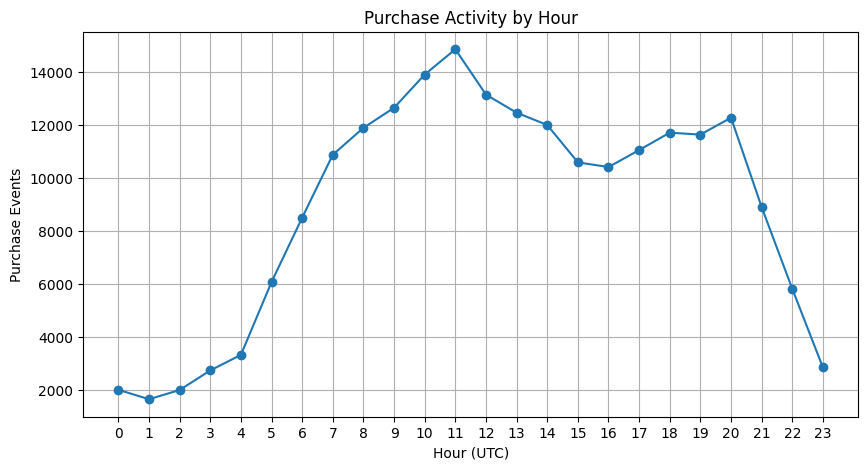

In [28]:
import matplotlib.pyplot as plt

hourly_purchases_sorted = (
    df[df["event_type"] == "purchase"]
    .groupby("hour")
    .size()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_purchases_sorted.index, hourly_purchases_sorted.values, marker="o")
plt.xlabel("Hour (UTC)")
plt.ylabel("Purchase Events")
plt.title("Purchase Activity by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [29]:
weekly_purchases = (
    df[df["event_type"] == "purchase"]
    .groupby("day_of_week")
    .size()
)

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekly_purchases = weekly_purchases.reindex(day_order)

print(weekly_purchases)

day_of_week
Monday       37171
Tuesday      34463
Wednesday    32250
Thursday     30220
Friday       26193
Saturday     22450
Sunday       30429
dtype: int64


In [30]:
purchase_revenue = (
    df[df["event_type"] == "purchase"]["price"].sum()
)

print(f"Total purchase value: {purchase_revenue:,.2f}")

Total purchase value: 1,077,624.85


In [31]:
daily_revenue = (
    df[df["event_type"] == "purchase"]
    .groupby("date")["price"]
    .sum()
    .sort_values(ascending=False)
)

daily_revenue.head(10)

date
2019-12-10    47542.27
2019-12-16    47316.07
2019-12-09    45978.20
2019-12-11    45395.76
2019-12-12    44951.44
2019-12-17    43714.89
2019-12-02    43304.28
2019-12-18    42605.93
2019-12-04    41233.50
2019-12-03    38703.91
Name: price, dtype: float64

In [32]:
brand_revenue = (
    df[df["event_type"] == "purchase"]
    .groupby("brand")["price"]
    .sum()
    .sort_values(ascending=False)
)

brand_revenue.head(15)

brand
runail       58177.26
grattol      43793.50
irisk        35291.51
uno          29084.76
estel        24474.19
jessnail     24075.00
strong       22266.41
masura       19809.19
cnd          19378.92
ingarden     18938.21
italwax      16133.72
marathon     13502.44
kapous       12477.03
pole         11813.66
browxenna    10886.98
Name: price, dtype: float64

In [33]:
brand_value_analysis = (
    df[df["event_type"] == "purchase"]
    .groupby("brand")
    .agg(
        purchase_events=("price", "count"),
        total_purchase_value=("price", "sum"),
        average_price=("price", "mean")
    )
    .sort_values("total_purchase_value", ascending=False)
)

brand_value_analysis.head(15)

,purchase_events,total_purchase_value,average_price
brand,,,
runail,18199,58177.26,3.196728
grattol,8171,43793.50,5.359626
irisk,10583,35291.51,3.334736
uno,2780,29084.76,10.462144
estel,4116,24474.19,5.946110
jessnail,1823,24075.00,13.206253
strong,120,22266.41,185.553417
masura,6985,19809.19,2.835961
cnd,1299,19378.92,14.918337


In [34]:
brand_scorecard = (
    df.groupby(["brand", "event_type"])
    .size()
    .unstack(fill_value=0)
)

brand_scorecard["purchase_value"] = (
    df[df["event_type"] == "purchase"]
    .groupby("brand")["price"]
    .sum()
)

brand_scorecard["avg_purchase_price"] = (
    df[df["event_type"] == "purchase"]
    .groupby("brand")["price"]
    .mean()
)

brand_scorecard["view_to_purchase_rate"] = (
    brand_scorecard["purchase"] /
    brand_scorecard["view"] * 100
)

brand_scorecard = brand_scorecard.fillna(0)

brand_scorecard.sort_values(
    "purchase_value",
    ascending=False
).head(20)

event_type,cart,purchase,remove_from_cart,view,purchase_value,avg_purchase_price,view_to_purchase_rate
brand,,,,,,,
runail,80411,18199,49510,108097,58177.26,3.196728,16.835805
grattol,37841,8171,26651,83257,43793.50,5.359626,9.814190
irisk,45841,10583,29565,66529,35291.51,3.334736,15.907349
uno,10567,2780,7817,20343,29084.76,10.462144,13.665634
estel,17946,4116,10287,44300,24474.19,5.946110,9.291196
jessnail,8450,1823,5197,34913,24075.00,13.206253,5.221551
strong,720,120,499,8966,22266.41,185.553417,1.338389
masura,33788,6985,34049,50363,19809.19,2.835961,13.869309
cnd,6180,1299,3776,20275,19378.92,14.918337,6.406905
